In [1]:



#spatial-temporal CNN for freegait

In [ ]:

import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np

DATA_PATH = Path("Datasets and splits/Freegait/FreeGait/FreeGait/native_csv_export/kp3d_native_wide.csv")
assert DATA_PATH.exists(), f"Dataset not found at {DATA_PATH}"

import random
import numpy as np
import torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE:", DEVICE)


DEVICE: cuda


In [3]:

# ==================== CONFIG ====================
WINDOW_SIZE = 29
OVERLAP = 14
TEST_RATIO = 0.20
VAL_RATIO  = 0.20

BATCH_SIZE = 64
EPOCHS = 1000
LEARNING_RATE = 1e-3

MAX_SESSIONS = None  # None = all sessions
# ================================================


In [4]:
import numpy as np

def fix_missdetected_joints(group, max_gap=500000, min_dup=4):
    #max gap for one second in this work because fps is 6
    """
    If, within the same frame, >= min_dup joints have EXACTLY the same (x,y,z),
    mark those joints as NaN and fill over time using linear interpolation.
    """
    joints = [
    "pelvis",
    "spine1", "spine2", "spine3",
    "neck", "head",

    "left_collar", "right_collar",
    "left_shoulder", "right_shoulder",
    "left_elbow", "right_elbow",
    "left_wrist", "right_wrist",
    "left_hand", "right_hand",
    "left_hip", "right_hip",
    "left_knee", "right_knee",
    "left_ankle", "right_ankle",
    "left_foot", "right_foot",

]

    #copy data frame 
    group = group.copy()
    #Build joint coordinate column names
    cols = [f"joint_{j}_{a}" for j in joints for a in "xyz"]
    #Convert to numpy and reshape to (T,J,3) where T is number of frames, J is number of joints
    arr = group[cols].to_numpy(float).reshape(len(group), len(joints), 3)
    #Mask for missdetected joints
    bad = np.zeros((len(group), len(joints)), dtype=bool)
    #Loop through each frame and find duplicates
    for t in range(len(group)):
        frame = arr[t]  # (J,3)
        #Ignore joints that already have NaNs in case it got used by CLS 
        valid = ~np.isnan(frame).any(axis=1)
        if valid.sum() < 2:
            continue

        # Find exact duplicate 3D coordinates in that frame
        uniq, inv, counts = np.unique(frame[valid], axis=0,
                                      return_inverse=True, return_counts=True)
        #Keep only coordinates repeated at least min_dup times
        dup_ids = np.where(counts >= min_dup)[0]
        if dup_ids.size == 0:
            continue
        #Mark those joints as bad
        dup_valid_mask = np.isin(inv, dup_ids)
        joint_idx = np.where(valid)[0][dup_valid_mask]
        joint_idx = joint_idx[joint_idx != torso_idx] # but never the torso
        bad[t, joint_idx] = True

    # Set duplicated joints to NaN (all 3 axes)
    arr[bad] = np.nan
    group.loc[:, cols] = arr.reshape(len(group), -1)

    # Fill from previous + next frames
    group.loc[:, cols] = (
        group.loc[:, cols]
             .interpolate(method="linear", limit=max_gap, limit_direction="both")
             .ffill(limit=max_gap)
             .bfill(limit=max_gap)
    )

    return group


In [5]:
import numpy as np

def make_windows(seq, label, window_size, step, pad_mode="edge"):
    """
    pad_mode:
      - "edge": repeat last frame 
      - "zero": pad with zeros
    """
    out_X, out_y = [], []
    T = len(seq)

    if T == 0:
        return out_X, out_y

    # If too short: pad and return exactly 1 window
    if T < window_size:
        seq = np.asarray(seq)
        pad_len = window_size - T

        if pad_mode == "edge":
            pad = np.repeat(seq[-1][None, :], pad_len, axis=0)
        elif pad_mode == "zero":
            pad = np.zeros((pad_len, seq.shape[1]), dtype=seq.dtype)
        else:
            raise ValueError("pad_mode must be 'edge' or 'zero'")

        win = np.vstack([seq, pad])
        out_X.append(win)
        out_y.append(label)
        return out_X, out_y

    # Normal sliding windows
    for start in range(0, T - window_size + 1, step):
        out_X.append(seq[start:start + window_size])
        out_y.append(label)

    return out_X, out_y


In [6]:

def make_windows_padded(seq, label, window_size, step, pad_mode="edge"):
    """
    Like make_windows, but if len(seq) < window_size it pads and returns exactly 1 window.
    """
    out_X, out_y = [], []
    seq = np.asarray(seq)
    T = len(seq)

    if T == 0:
        return out_X, out_y

    if T < window_size:
        pad_len = window_size - T
        if pad_mode == "edge":
            pad = np.repeat(seq[-1][None, :], pad_len, axis=0)
        elif pad_mode == "zero":
            pad = np.zeros((pad_len, seq.shape[1]), dtype=seq.dtype)
        else:
            raise ValueError("pad_mode must be 'edge' or 'zero'")
        win = np.vstack([seq, pad])
        out_X.append(win)
        out_y.append(label)
        return out_X, out_y

    for start in range(0, T - window_size + 1, step):
        out_X.append(seq[start:start + window_size])
        out_y.append(label)

    return out_X, out_y

In [7]:
    import numpy as np

    def preprocess_features_split(
        df,
        window_size,
        overlap,
        test_session_ratio=0.20,
        val_session_ratio=0.16,   
        seed=42,
        fps=10,
        fc=2.5,
        min_seqs_per_person=30,
        max_seqs_per_person=None,
        remove_trajectory=True,
        use_padded_windows=True,
    ):
        """
        

        Returns:
        X_train: (Ntr, window_size, F)
        y_train: (Ntr,)
        X_test:  (Nts, window_size, F)
        y_test:  (Nts,)
        feat_cols: list[str]
        """

        # session_id
        if "session_id" not in df.columns:
            df = df.copy()
            df["session_id"] = (
                df["person"].astype(str) + "-" +
                df["device"].astype(str) + "-" +
                df["sequence"].astype(str)
            )

        # columns / params
        joint_order = [
              "pelvis","spine1","spine2","spine3","neck","head",
              "left_collar","right_collar",
             "left_shoulder","right_shoulder",
                 "left_elbow","right_elbow",
              "left_wrist","right_wrist",
                  "left_hand","right_hand",
              "left_hip","right_hip",
             "left_knee","right_knee",
             "left_ankle","right_ankle",
             "left_foot","right_foot",
            ]
        axes = ["x","y","z"]
        joint_cols = [f"joint_{j}_{a}" for j in joint_order for a in axes]
        feat_cols = joint_cols
    
        grouped = df.groupby(["person", "session_id"], sort=False)
        sessions_by_person = {}
        step = max(1, window_size - overlap)
        rng = np.random.default_rng(seed)

        for (person, session_id), group in grouped:
            group = group.sort_values("frame").reset_index(drop=True).copy()
            group = group.dropna(subset=joint_cols).reset_index(drop=True)

            if len(group) == 0:
                continue

            if remove_trajectory:
                for ax in ("x", "y", "z"):
                    pel = group[f"joint_pelvis_{ax}"].to_numpy()
                    cols_ax = [c for c in joint_cols if c.endswith(f"_{ax}")]
                    group.loc[:, cols_ax] = group.loc[:, cols_ax].to_numpy() - pel[:, None]

            # raw coords only, in forced order:
            feats = group[joint_cols].to_numpy(dtype=np.float32)  # (T, 72)

            sessions_by_person.setdefault(str(person), []).append((str(session_id), feats))

        # nothing usable
        if not sessions_by_person:
            return (
                np.empty((0, window_size, 0), dtype=np.float32),
                np.empty((0,), dtype=object),
                np.empty((0, window_size, 0), dtype=np.float32),
                np.empty((0,), dtype=object),
                np.empty((0, window_size, 0), dtype=np.float32),
                np.empty((0,), dtype=object),
                joint_cols,
            )

        # Split sessions per person -> window samples
        X_train, y_train, X_val, y_val, X_test, y_test = [], [], [], [], [], []
        kept_people = 0
        dropped_people = 0

        win_fn = make_windows_padded if use_padded_windows else make_windows

        for person, sess_list in sessions_by_person.items():
            eligible = sess_list[:] if use_padded_windows else [
                (sid, feats) for (sid, feats) in sess_list if len(feats) >= window_size
            ]

            n = len(eligible)
            if n == 0:
                continue

            if n < min_seqs_per_person:
                dropped_people += 1
                continue

            if max_seqs_per_person is not None and n > max_seqs_per_person:
                eligible.sort(key=lambda x: x[0])
                eligible = eligible[:max_seqs_per_person]
                n = len(eligible)

            kept_people += 1

            # deterministic order before random split
            eligible.sort(key=lambda x: x[0])
            perm = rng.permutation(n)

            # choose counts
            n_test = int(np.ceil(n * test_session_ratio))
            n_val  = int(np.ceil(n * val_session_ratio))

            # ensure at least 1 train session
            n_test = max(1, min(n_test, n - 1))

            # only make a val split if there is room (need at least 1 train after test+val)
            if n - n_test <= 1:
                n_val = 0
            else:
                n_val = max(1, min(n_val, n - n_test - 1))

            test_idx = set(perm[:n_test].tolist())
            val_idx  = set(perm[n_test:n_test + n_val].tolist())

            for i, (sid, feats) in enumerate(eligible):
                Xw, yw = win_fn(feats, person, window_size, step)
                if i in test_idx:
                    X_test.extend(Xw); y_test.extend(yw)
                elif i in val_idx:
                    X_val.extend(Xw); y_val.extend(yw)
                else:
                    X_train.extend(Xw); y_train.extend(yw)

        print(f"[split] kept persons={kept_people}, dropped persons={dropped_people}")
        print(f"[split] train windows={len(X_train)}, val windows={len(X_val)}, test windows={len(X_test)}")

        return (
            np.asarray(X_train, dtype=np.float32),
            np.asarray(X_val, dtype=np.float32),
            np.asarray(X_test, dtype=np.float32),
            np.asarray(y_train),
            np.asarray(y_val),
            np.asarray(y_test),
            feat_cols,
        )

In [8]:

import pandas as pd


df = pd.read_csv(DATA_PATH, low_memory=False)


X_train, X_val, X_test, y_train, y_val, y_test, _  = preprocess_features_split(df,WINDOW_SIZE, OVERLAP, min_seqs_per_person=50)
#for debugging
print("Train:", X_train.shape, "| Val:", X_val.shape, "| Test:", X_test.shape)
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)
classes = list(le.classes_)
#for debugging
print("Classes:", classes)
#for debugging
print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)


[split] kept persons=7, dropped persons=1188
[split] train windows=278, val windows=72, test windows=85
Train: (278, 29, 72) | Val: (72, 29, 72) | Test: (85, 29, 72)
Classes: [np.str_('1150'), np.str_('1165'), np.str_('1191'), np.str_('1194'), np.str_('1206'), np.str_('1229'), np.str_('1235')]
Train: (278, 29, 72) Val: (72, 29, 72) Test: (85, 29, 72)


In [9]:
from torch.utils.data import Dataset, DataLoader
import torch

from torch.utils.data import Dataset
import torch

class WindowDataset(Dataset):
    def __init__(self, X, y, J=24, C=3):
        X = torch.as_tensor(X, dtype=torch.float32)  # (N, T, 45)
        y = torch.as_tensor(y, dtype=torch.long)
        self.X = X.reshape(X.shape[0], X.shape[1], J, C)  # (N, T, J, C)
        self.y = y

    def __len__(self): return self.X.shape[0]
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

train_ds = WindowDataset(X_train, y_train_enc, J=24, C=3)
val_ds   = WindowDataset(X_val,   y_val_enc,   J=24, C=3)
test_ds  = WindowDataset(X_test,  y_test_enc,  J=24, C=3)

g = torch.Generator()
g.manual_seed(42)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, generator=g, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)


In [10]:
import torch.nn as nn
import torch.nn.functional as F

class STCNN(nn.Module):
    def __init__(self, n_classes, C=3):
        super().__init__()
        self.t1 = nn.Conv2d(C,   64, (1,5), padding=(0,2))
        self.s1 = nn.Conv2d(64, 64, kernel_size=(3, 1), padding=(1, 0))
        self.bn1 = nn.BatchNorm2d(64)

        self.t2 = nn.Conv2d(64, 128, kernel_size=(1, 5), padding=(0, 2))
        self.s2 = nn.Conv2d(128, 128, kernel_size=(3, 1), padding=(1, 0))
        self.bn2 = nn.BatchNorm2d(128)

        self.t3 = nn.Conv2d(128, 256, kernel_size=(1, 5), padding=(0, 2))
        self.s3 = nn.Conv2d(256, 256, kernel_size=(3, 1), padding=(1, 0))
        self.bn3 = nn.BatchNorm2d(256)

        self.drop = nn.Dropout(0.3)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(256, n_classes)
    def forward(self, x):
        # x: (B, T, J, C)
        x = x.permute(0, 3, 2, 1).contiguous()  # (B, C, J, T)

        x = F.relu(self.bn1(self.s1(self.t1(x))))
        x = self.drop(x)
        x = F.relu(self.bn2(self.s2(self.t2(x))))
        x = self.drop(x)
        x = F.relu(self.bn3(self.s3(self.t3(x))))
        x = self.drop(x)

        x = self.pool(x).squeeze(-1).squeeze(-1)  # (B, 256)
        return self.fc(x)
n_classes = len(classes)
model = STCNN(n_classes=n_classes, C=3).to(DEVICE)
print(model)

STCNN(
  (t1): Conv2d(3, 64, kernel_size=(1, 5), stride=(1, 1), padding=(0, 2))
  (s1): Conv2d(64, 64, kernel_size=(3, 1), stride=(1, 1), padding=(1, 0))
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (t2): Conv2d(64, 128, kernel_size=(1, 5), stride=(1, 1), padding=(0, 2))
  (s2): Conv2d(128, 128, kernel_size=(3, 1), stride=(1, 1), padding=(1, 0))
  (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (t3): Conv2d(128, 256, kernel_size=(1, 5), stride=(1, 1), padding=(0, 2))
  (s3): Conv2d(256, 256, kernel_size=(3, 1), stride=(1, 1), padding=(1, 0))
  (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop): Dropout(p=0.3, inplace=False)
  (pool): AdaptiveAvgPool2d(output_size=(1, 1))
  (fc): Linear(in_features=256, out_features=7, bias=True)
)


logits shape: torch.Size([64, 7])
Class counts: [38 35 54 36 36 40 39]
Class weights: tensor([1.0451, 1.1347, 0.7354, 1.1032, 1.1032, 0.9929, 1.0183],
       device='cuda:0')
Epoch 1 | TrainLoss 1.9070 | ValLoss 1.9579 | ValF1 0.032
Epoch 1/1000 - Val Acc: 0.032 | Val F1: 0.032 | LR: 0.001 | best=0.032 bad_epochs=0 | Conf mean=0.197 (correct=0.197, wrong=0.197)
Epoch 2 | TrainLoss 1.6781 | ValLoss 2.5132 | ValF1 0.032
Epoch 2/1000 - Val Acc: 0.032 | Val F1: 0.032 | LR: 0.001 | best=0.032 bad_epochs=1 | Conf mean=0.417 (correct=0.417, wrong=0.417)
Epoch 3 | TrainLoss 1.6255 | ValLoss 4.2780 | ValF1 0.032
Epoch 3/1000 - Val Acc: 0.032 | Val F1: 0.032 | LR: 0.001 | best=0.032 bad_epochs=2 | Conf mean=0.511 (correct=0.514, wrong=0.511)
Epoch 4 | TrainLoss 1.5029 | ValLoss 5.9695 | ValF1 0.062
Epoch 4/1000 - Val Acc: 0.062 | Val F1: 0.062 | LR: 0.001 | best=0.062 bad_epochs=0 | Conf mean=0.506 (correct=0.505, wrong=0.507)
Epoch 5 | TrainLoss 1.4508 | ValLoss 6.8082 | ValF1 0.032
Epoch 5/100

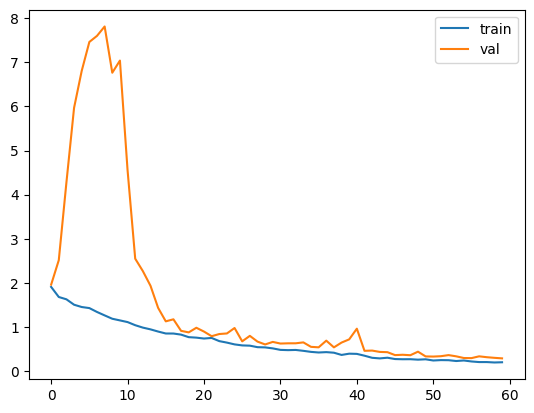

Test Acc: 0.930 | Test F1: 0.930 | TestLoss: 0.3861
Test mean confidence: 0.773
              precision    recall  f1-score   support

           0      1.000     1.000     1.000        11
           1      1.000     0.900     0.947        10
           2      0.941     0.762     0.842        21
           3      0.909     1.000     0.952        10
           4      1.000     1.000     1.000        11
           5      0.688     1.000     0.815        11
           6      1.000     0.909     0.952        11

    accuracy                          0.918        85
   macro avg      0.934     0.939     0.930        85
weighted avg      0.934     0.918     0.919        85

Sample test preds (true, pred, conf):
  0 -> 0  conf=0.950
  0 -> 0  conf=0.940
  0 -> 0  conf=0.900
  0 -> 0  conf=0.860
  0 -> 0  conf=0.902
  0 -> 0  conf=0.759
  0 -> 0  conf=0.436
  0 -> 0  conf=0.659
  0 -> 0  conf=0.734
  0 -> 0  conf=0.415
  0 -> 0  conf=0.797
  1 -> 1  conf=0.864
  1 -> 1  conf=0.815
  1 -> 1  co

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import f1_score

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
)

# ---------- sanity check (BEFORE training) ----------
model.eval()
X0, y0 = next(iter(train_loader))
logits0 = model(X0.to(DEVICE))
print("logits shape:", logits0.shape)  # should be (batch_size, n_classes)

# ---------- class weights ----------
num_classes = n_classes
class_counts = np.bincount(y_train_enc, minlength=num_classes)
print(f"Class counts: {class_counts}")

class_weights = class_counts.sum() / (num_classes * class_counts)
class_weights[class_counts == 0] = 0.0  # safety if any class missing in train
class_weights = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)
print(f"Class weights: {class_weights}")

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=5
)

# ---------- evaluation (WITH CONFIDENCE PER PREDICTION) ----------
def evaluate(loader):
    
    model.eval(); y_true=[]; y_pred=[]; y_conf=[]; val_loss = 0.0; n = 0

    with torch.no_grad():
        for X, y in loader:
            X = X.to(DEVICE)
            y = y.to(DEVICE).long()

            logits = model(X)                       # (B, C)
            probs = torch.softmax(logits, dim=1)     # (B, C)

            conf, preds = probs.max(dim=1)           # (B,), (B,)
            batch_loss = criterion(logits, y).item()
            val_loss += batch_loss * X.size(0); n += X.size(0)

            y_true.extend(y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())
            y_conf.extend(conf.cpu().numpy())

    f1_score_val = f1_score(y_true, y_pred, average='macro')
    return f1_score_val, np.array(y_true), np.array(y_pred), np.array(y_conf), val_loss / max(1, n)
best_metric = -float("inf")
patience_es = 10          # stop after 10 epochs with no improvement
min_delta = 1e-4          # required improvement to count as "better"
epochs_no_improve = 0
best_state = None
train_losses, val_losses = [], [] 

# ---------- training ----------
for epoch in range(1, EPOCHS + 1):
    model.train()
    batch_losses = []   
    for X, y in train_loader:
        X = X.to(DEVICE)
        y = y.to(DEVICE).long()

        optimizer.zero_grad()
        logits = model(X)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    train_loss = float(np.mean(batch_losses))
    train_losses.append(train_loss)
    # --- validation ---
    val_acc, y_true, y_pred, y_conf, val_loss = evaluate(val_loader)
    val_losses.append(val_loss)
    val_f1 = f1_score(y_true, y_pred, average='macro')
    metric = val_f1
    print(f"Epoch {epoch} | TrainLoss {train_loss:.4f} | ValLoss {val_loss:.4f} | ValF1 {val_f1:.3f}")
    if metric > best_metric + min_delta:
        best_metric = metric
        epochs_no_improve = 0
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= patience_es:
       print(f"Early stopping at epoch {epoch} (best metric={best_metric:.3f})")
       break
    old_lr = optimizer.param_groups[0]["lr"]
    scheduler.step(val_f1)  # scheduling on f1
    new_lr = optimizer.param_groups[0]["lr"]

    correct = (y_true == y_pred)
    mean_conf = float(y_conf.mean()) if len(y_conf) else float("nan")
    mean_conf_correct = float(y_conf[correct].mean()) if correct.any() else float("nan")
    mean_conf_wrong = float(y_conf[~correct].mean()) if (~correct).any() else float("nan")

    print(
        f"Epoch {epoch}/{EPOCHS} - "
        f"Val Acc: {val_acc:.3f} | Val F1: {val_f1:.3f} | "
        f"LR: {new_lr:.6g} | best={scheduler.best:.3f} bad_epochs={scheduler.num_bad_epochs} | "
        f"Conf mean={mean_conf:.3f} (correct={mean_conf_correct:.3f}, wrong={mean_conf_wrong:.3f})"
    )

    if new_lr != old_lr:
        print(f"  >>> LR reduced: {old_lr:.6g} -> {new_lr:.6g}")

    if epoch % 5 == 0:
        print(classification_report(y_true, y_pred, digits=3, zero_division=0))
        # show a few sample predictions with confidence
        k = min(10, len(y_true))
        print("Sample val preds (true, pred, conf):")
        for i in range(k):
            print(f"  {y_true[i]} -> {y_pred[i]}  conf={y_conf[i]:.3f}")
plt.plot(train_losses, label="train"); plt.plot(val_losses, label="val"); plt.legend(); plt.show()
# ---------- final evaluation on test set ----------
if best_state is not None:
    model.load_state_dict(best_state)
    model.to(DEVICE)

test_acc, y_true, y_pred, y_conf, test_loss = evaluate(test_loader)
test_f1 = f1_score(y_true, y_pred, average='macro')
print(f"Test Acc: {test_acc:.3f} | Test F1: {test_f1:.3f} | TestLoss: {test_loss:.4f}")

print(f"Test mean confidence: {float(y_conf.mean()):.3f}")

print(classification_report(y_true, y_pred, digits=3, zero_division=0))

# show a few test predictions with confidence for debugging
k =  len(y_true)
print("Sample test preds (true, pred, conf):")
for i in range(k):
    print(f"  {y_true[i]} -> {y_pred[i]}  conf={y_conf[i]:.3f}")


In [12]:
# plotting functions

#1) confusion matrix plotting function
def plot_confusion_matrices(y_true, y_pred, savepath=None, title_prefix="Confusion Matrix"):
    
    labels_present = sorted(set(y_true) | set(y_pred), key=str)
    cm = confusion_matrix(y_true, y_pred, labels=labels_present)

    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums!=0)

    n_cls = len(labels_present)
    fig_w = max(12, 0.7 * n_cls + 8)
    fig_h = max(6,  0.7 * n_cls + 3)

    fig, axes = plt.subplots(1, 2, figsize=(fig_w, fig_h), constrained_layout=True)
    fig.set_dpi(150)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, square=True,
                linewidths=0.5, linecolor="white",
                xticklabels=[str(l) for l in labels_present],
                yticklabels=[str(l) for l in labels_present],
                annot_kws={"size": 12}, ax=axes[0])
    axes[0].set_title(f"{title_prefix} (counts)")
    axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")

    sns.heatmap(cm_norm*100, annot=True, fmt=".1f", cmap="Blues", cbar=False, vmin=0, vmax=100, square=True,
                linewidths=0.5, linecolor="white",
                xticklabels=[str(l) for l in labels_present],
                yticklabels=[str(l) for l in labels_present],
                annot_kws={"size": 12}, ax=axes[1])
    axes[1].set_title(f"{title_prefix} (row-normalized, %)")
    axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")

    for ax in axes:
        for lbl in ax.get_xticklabels():
            lbl.set_rotation(45); lbl.set_ha("right"); lbl.set_fontsize(10)
        for lbl in ax.get_yticklabels():
            lbl.set_fontsize(10)

    if savepath:
        os.makedirs(os.path.dirname(savepath), exist_ok=True)
        fig.savefig(savepath, dpi=300)
        print(f"Saved confusion matrices to {savepath}")

    plt.show()
# 2) per-class precision/recall/f1 bar plot
def plot_per_class_report(y_true, y_pred, class_names):
    rep = classification_report(y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0)
    classes = class_names
    metrics = ['precision','recall','f1-score']
    data = np.array([[rep[c][m] for c in classes] for m in metrics])

    fig, ax = plt.subplots(figsize=(10, 4 + 0.2*len(classes)))
    x = np.arange(len(classes)); w = 0.25
    for i, m in enumerate(metrics):
        ax.bar(x + (i-1)*w, data[i], width=w, label=m)
    ax.set_xticks(x); ax.set_xticklabels(classes, rotation=45, ha='right')
    ax.set_ylim(0,1); ax.set_ylabel('score'); ax.set_title('Per-class metrics')
    ax.legend(); plt.tight_layout()

@torch.no_grad()

def get_probs(loader, model, device):
    model.eval()
    ys, probs = [], []
    for X, y in loader:
        X = X.to(device)
        logits = model(X)
        p = torch.softmax(logits, dim=1).cpu().numpy()
        probs.append(p); ys.append(y.numpy())
    return np.concatenate(ys), np.concatenate(probs)
# 4) Random window visualization
def plot_random_window(X_windows, y_labels=None, feature_names=None, idx=None, title='Random window'):
    if len(X_windows) == 0: 
        print("No windows."); return
    if idx is None: 
        idx = np.random.randint(len(X_windows))
    W = X_windows[idx]  # (W,F)
    fig, ax = plt.subplots(figsize=(10,4))
    ax.plot(W)
    t = f"{title} #{idx}" + (f" | label: {y_labels[idx]}" if y_labels is not None else "")
    ax.set_title(t); ax.set_xlabel('timestep'); ax.set_ylabel('feature value')
    if feature_names and len(feature_names) == W.shape[1]:
        ax.legend([feature_names[i] for i in range(W.shape[1])], ncol=4, fontsize=8)
    plt.tight_layout()


Validation Accuracy: 0.9532336858188252
              precision    recall  f1-score   support

        1150       1.00      0.89      0.94         9
        1165       1.00      0.78      0.88         9
        1191       1.00      1.00      1.00        17
        1194       1.00      1.00      1.00         9
        1206       1.00      1.00      1.00         9
        1229       0.90      1.00      0.95         9
        1235       0.83      1.00      0.91        10

    accuracy                           0.96        72
   macro avg       0.96      0.95      0.95        72
weighted avg       0.96      0.96      0.96        72

Saved confusion matrices to figs/cnn_cm_val.png


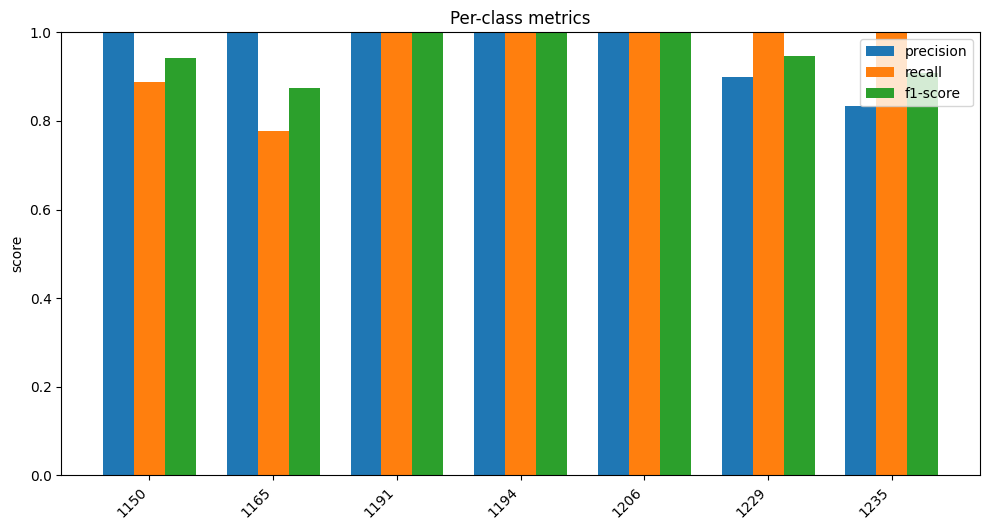

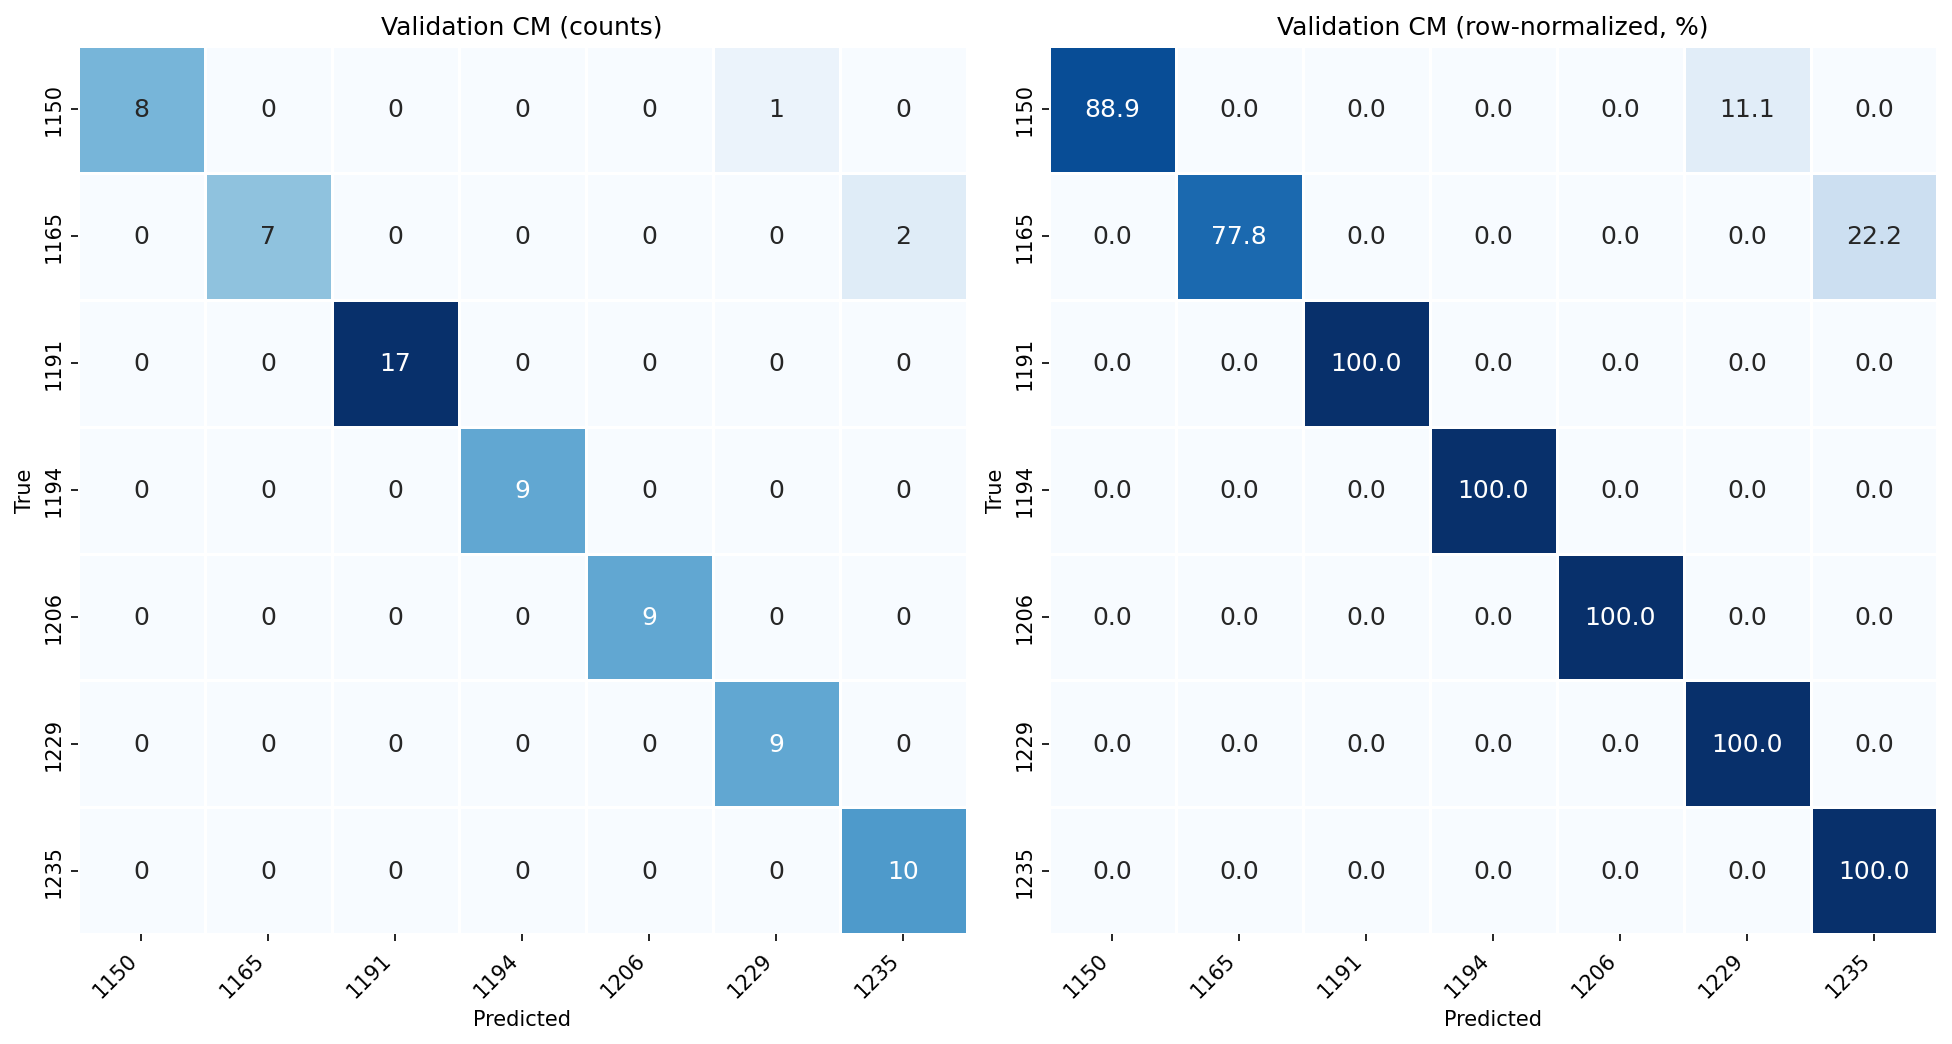

Test Accuracy: 0.9298643433981779
              precision    recall  f1-score   support

        1150       1.00      1.00      1.00        11
        1165       1.00      0.90      0.95        10
        1191       0.94      0.76      0.84        21
        1194       0.91      1.00      0.95        10
        1206       1.00      1.00      1.00        11
        1229       0.69      1.00      0.81        11
        1235       1.00      0.91      0.95        11

    accuracy                           0.92        85
   macro avg       0.93      0.94      0.93        85
weighted avg       0.93      0.92      0.92        85

Saved confusion matrices to figs/cnn_cm_test.png


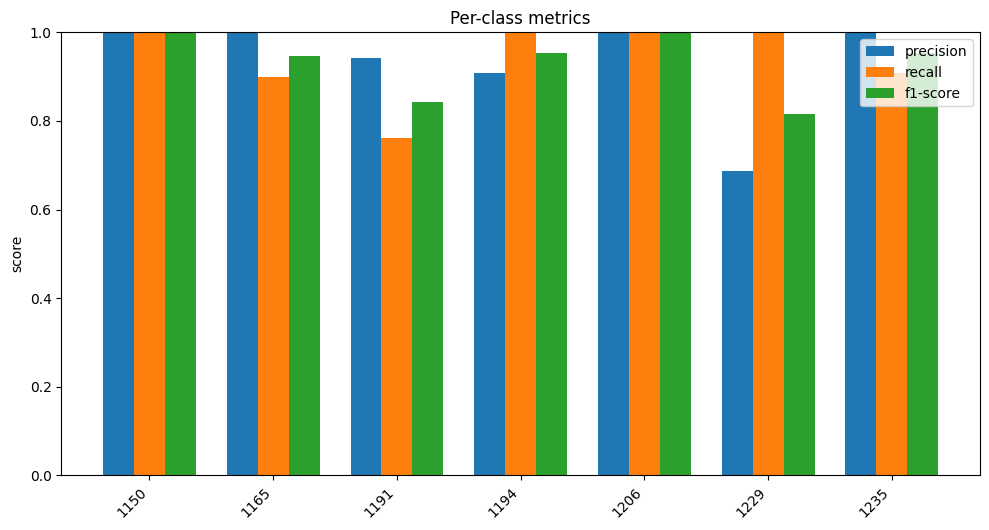

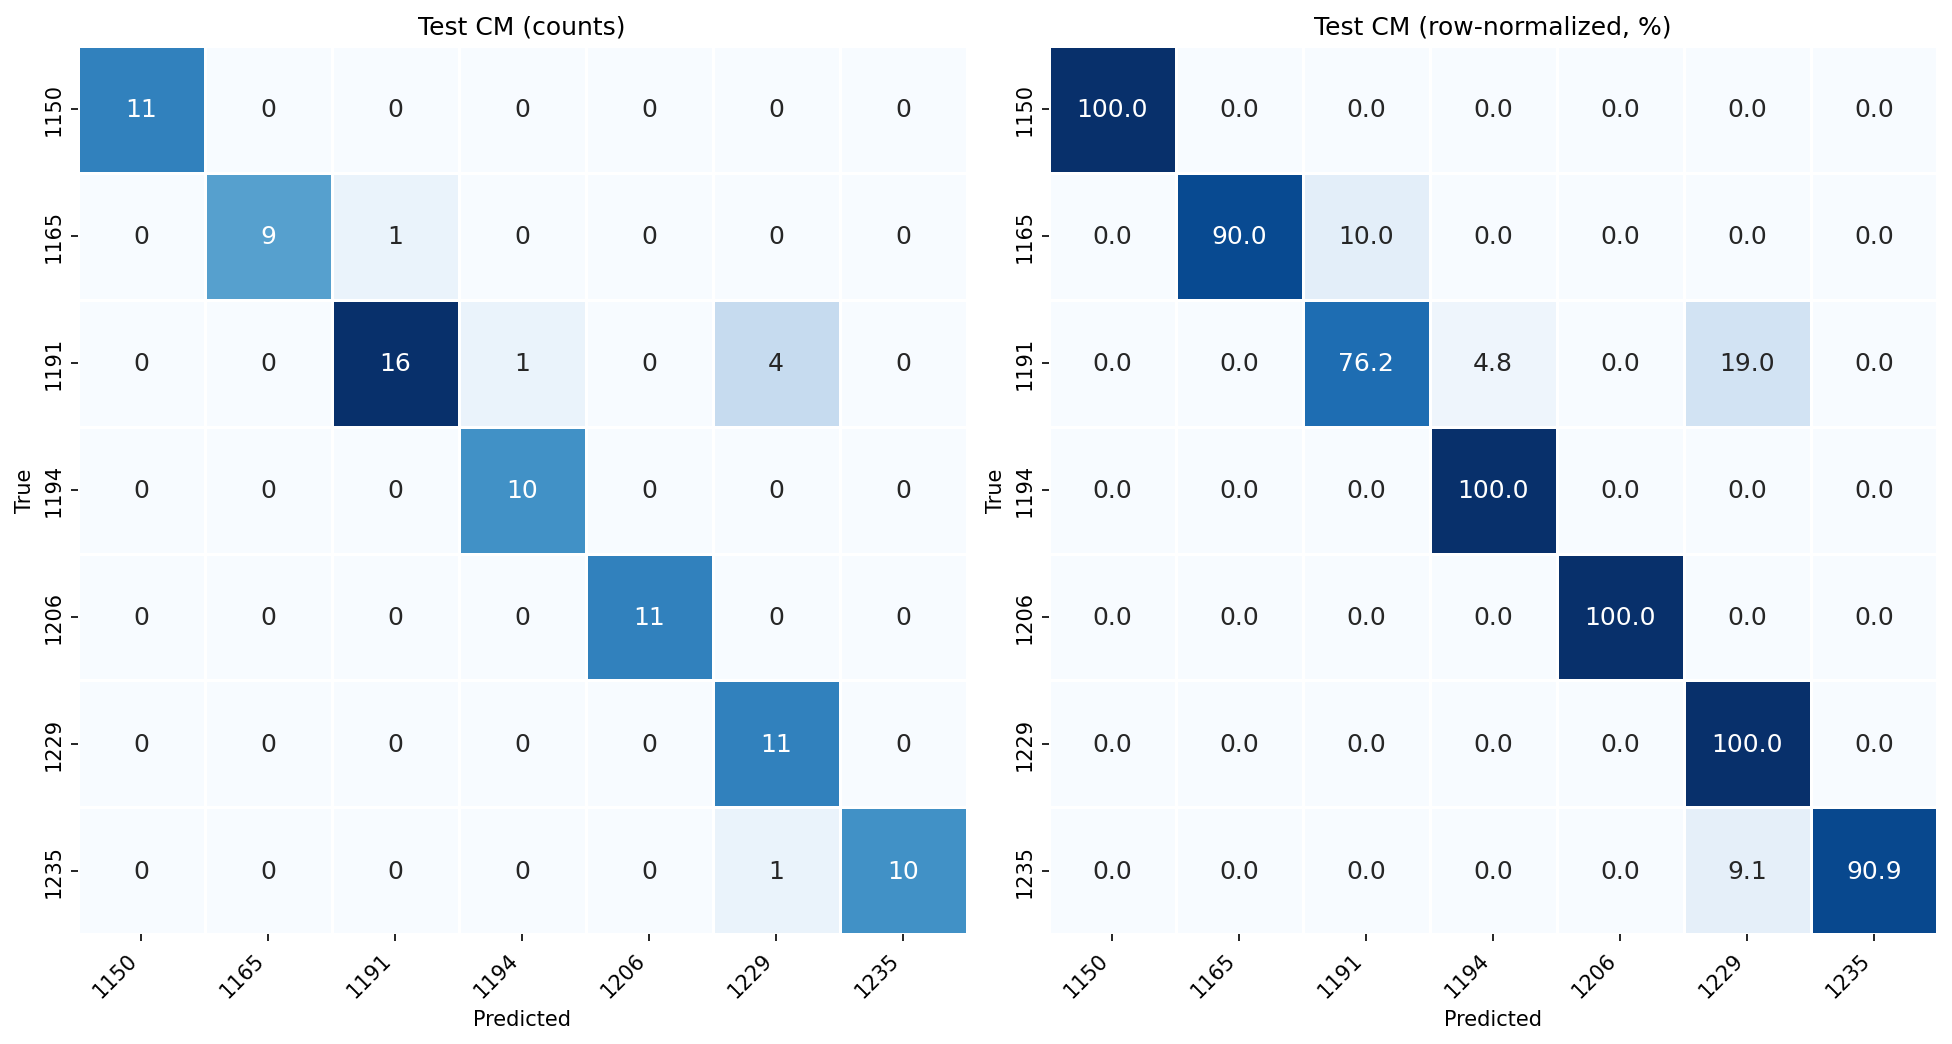

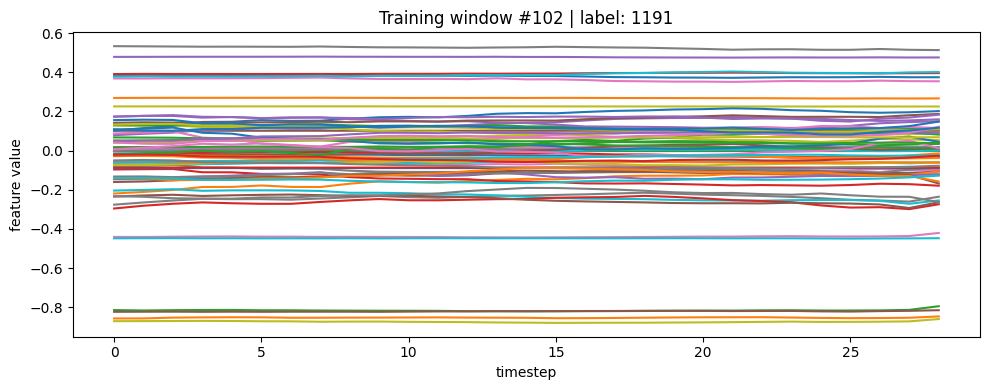

In [13]:
import os
import seaborn as sns
from sklearn.metrics import roc_curve, auc, classification_report
from sklearn.preprocessing import label_binarize

# Validation report

val_acc, y_true_val, y_pred_val, *_ = evaluate(val_loader)
print("Validation Accuracy:", val_acc)

cls = np.array(classes)
y_true_val_n = cls[np.asarray(y_true_val)]
y_pred_val_n = cls[np.asarray(y_pred_val)]
# classification report
print(classification_report(y_true_val, y_pred_val, target_names=classes))

#class-wise metrics and confusion matrices
plot_per_class_report(y_true_val_n, y_pred_val_n, classes)
plot_confusion_matrices(y_true_val_n, y_pred_val_n,
                        savepath="figs/cnn_cm_val.png",
                        title_prefix="Validation CM")

# Test report

test_acc, y_true_test, y_pred_test, *_ = evaluate(test_loader)
y_true_test_n = cls[np.asarray(y_true_test)]
y_pred_test_n = cls[np.asarray(y_pred_test)]
print("Test Accuracy:", test_acc)
# classification report
print(classification_report(y_true_test, y_pred_test, target_names=classes))


#class-wise metrics and confusion matrices
plot_per_class_report(y_true_test_n, y_pred_test_n, classes)

plot_confusion_matrices(y_true_test_n, y_pred_test_n,
                        savepath="figs/cnn_cm_test.png",
                        title_prefix="Test CM")
# Get test probabilities for ROC
y_true_test_probs, y_prob_test = get_probs(test_loader, model, DEVICE)
# Random window visualization
plot_random_window(X_train, y_train, title='Training window')
